# Plan a real robot arm in V-JEPA 2's feature space — V-JEPA 2-AC, small scale

**Lecture 12 · V-JEPA 2 and V-JEPA 2-AC** — *Build a World Model from Scratch* (Vizuara)

V-JEPA 2-AC turns a video encoder into a robot world model in three moves — and we'll make all three on a
**real SO-101 arm**:

1. **Freeze** the pretrained V-JEPA 2 encoder. It already learned how the world looks and moves from millions of
   internet videos; we never update it.
2. **Train an action-conditioned predictor** on a little robot data: given the latents of the frames so far, the
   robot's state and the actions, predict the latents of the next frame. Two losses, exactly as in the lecture:
   **teacher forcing** (predict each next step from the true past) and **rollout** (feed the predictor its own
   predictions, the way it will be used for planning).
3. **Plan with CEM**: give a start frame and a goal frame, search for the action sequence whose *imagined* final
   latent is closest to the goal's latent — then check against the actions the human operator actually took.

Meta trained the real V-JEPA 2-AC (ViT-g, 1B parameters) on 62 hours of robot video. We use the ViT-L encoder
(326M, frozen) and 50 episodes (~7 minutes of data), so this runs on a free Colab T4 in about 15 minutes.

In [1]:
!pip install -q lerobot transformers


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import math, random, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

device: cuda Tesla T4


## 1. The frozen encoder: V-JEPA 2 (ViT-L)

V-JEPA 2 is a *video* encoder: it cuts a clip into 2-frame × 16×16-pixel tubelets. Feeding it a 2-frame clip of
256×256 gives a 16×16 grid of 1024-dimensional tokens. We give it the same frame twice (a "still" clip), so each
robot observation becomes one 16×16×1024 latent grid — then we average-pool it to 4×4 to keep the predictor small.

In [3]:
from transformers import AutoModel

encoder = AutoModel.from_pretrained("facebook/vjepa2-vitl-fpc64-256", torch_dtype=torch.float16).to(device).eval()
for p in encoder.parameters():
    p.requires_grad_(False)
print(f"V-JEPA 2 encoder: {sum(p.numel() for p in encoder.parameters())/1e6:.0f}M parameters (frozen)")

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 1, 3, 1, 1)

@torch.no_grad()
def encode(imgs):
    # imgs: (B, 3, H, W) float in [0, 1]  ->  (B, 16, 1024) pooled latent tokens
    x = F.interpolate(imgs.to(device).float(), size=(256, 256), mode="bilinear", antialias=True)
    clip = x.unsqueeze(1).repeat(1, 2, 1, 1, 1)                     # (B, 2, 3, 256, 256): a still clip
    clip = ((clip - MEAN) / STD).half()
    tok = encoder.get_vision_features(clip)                          # (B, 256, 1024)
    grid = tok.float().view(-1, 16, 16, 1024).permute(0, 3, 1, 2)   # (B, 1024, 16, 16)
    return F.adaptive_avg_pool2d(grid, 4).flatten(2).transpose(1, 2).cpu()   # (B, 16, 1024)

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

V-JEPA 2 encoder: 326M parameters (frozen)


## 2. Robot data → latents, states and actions

`lerobot/svla_so101_pickplace`: 50 teleoperated pick-and-place episodes at 30 fps. Like V-JEPA 2-AC (and LeWM's
`frameskip=5`), we work at **6 Hz**: one step = 5 raw frames. For every step we store

- `z` — the frozen V-JEPA 2 latent of the top-camera frame,
- `s` — the arm's 6 joint positions (the proprioceptive state),
- `a` — the action, defined as the change in joint positions to the next step, `a = s(t+1) − s(t)`.

That definition gives us a free, exact state update during imagination: `s(t+1) = s(t) + a(t)`.
Five whole episodes are held out for testing.

In [4]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

ds = LeRobotDataset("lerobot/svla_so101_pickplace")
CAM, FS = "observation.images.up", 5
frame_idx = np.asarray(ds.hf_dataset["frame_index"])
keep = np.where(frame_idx % FS == 0)[0]
print(f"{ds.num_episodes} episodes, {ds.num_frames} frames -> {len(keep)} steps at {ds.fps // FS} Hz")

Z, S, E, thumbs = [], [], [], []
loader = torch.utils.data.DataLoader(torch.utils.data.Subset(ds, keep.tolist()), batch_size=32, num_workers=2)
t0 = time.time()
for b in tqdm(loader, desc="encoding with V-JEPA 2"):
    Z.append(encode(b[CAM]).half()); S.append(b["observation.state"].float()); E.append(b["episode_index"])
    thumbs.append((F.interpolate(b[CAM], size=(96, 128), mode="bilinear") * 255).byte())
Z, S, E, thumbs = torch.cat(Z), torch.cat(S), torch.cat(E), torch.cat(thumbs)
print(f"latents {tuple(Z.shape)} in {time.time()-t0:.0f}s")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

stats.json: 0.00B [00:00, ?B/s]

meta/episodes/chunk-000/file-000.parquet:   0%|          | 0.00/72.6k [00:00<?, ?B/s]

info.json: 0.00B [00:00, ?B/s]

meta/tasks.parquet:   0%|          | 0.00/2.25k [00:00<?, ?B/s]

...

data/chunk-000/file-000.parquet:   0%|          | 0.00/370k [00:00<?, ?B/s]

videos/observation.images.up/chunk-000/f(…):   0%|          | 0.00/40.1M [00:00<?, ?B/s]

50 episodes, 11939 frames -> 2410 steps at 6 Hz


encoding with V-JEPA 2:   0%|          | 0/76 [00:00<?, ?it/s]

latents (2410, 16, 1024) in 33s


In [5]:
test_eps = [45, 46, 47, 48, 49]
T_CTX = 4                                   # windows of 4 steps: z0..z3, actions a0..a2
windows = []
for e in E.unique().tolist():
    idx = torch.where(E == e)[0]
    windows += [(idx[i:i + T_CTX], e) for i in range(len(idx) - T_CTX + 1)]
train_w = torch.stack([w for w, e in windows if e not in test_eps])
test_w = torch.stack([w for w, e in windows if e in test_eps])

A_all = torch.zeros_like(S)
A_all[:-1] = S[1:] - S[:-1]                 # a(t) = s(t+1) - s(t); only used inside windows, never across episodes
tr_steps = train_w[:, :-1].reshape(-1)
z_mu, z_sd = Z[train_w.reshape(-1)].float().mean((0, 1)), Z[train_w.reshape(-1)].float().std((0, 1)) + 1e-4
s_mu, s_sd = S[tr_steps].mean(0), S[tr_steps].std(0) + 1e-4
a_sd = A_all[tr_steps].std(0) + 1e-4
Zn = (Z.float() - z_mu) / z_sd
print(f"train windows {len(train_w)}, test windows {len(test_w)}; typical |action| per joint: {a_sd.numpy().round(1)}")

train windows 2002, test windows 258; typical |action| per joint: [8.8 8.5 6.1 5.2 3.6 3.4]


## 3. The action-conditioned predictor

Each step contributes 18 tokens: 16 latent tokens (projected 1024 → 256), one **action** token and one **state**
token. A small transformer with a **block-causal** mask — tokens see their own step and the past, never the
future — reads the sequence and, at each step, outputs a prediction of the next step's 16 latents.
This is the same shape as DINO-WM's predictor (Lecture 10); the difference V-JEPA 2-AC adds is *which* encoder
sits in front of it and the rollout loss.

In [6]:
class ACPredictor(nn.Module):
    def __init__(self, d_lat=1024, d=256, n_tok=16, depth=4, heads=4, steps=T_CTX):
        super().__init__()
        self.n_tok = n_tok
        self.inp = nn.Linear(d_lat, d)
        self.act = nn.Sequential(nn.Linear(6, d), nn.GELU(), nn.Linear(d, d))
        self.state = nn.Sequential(nn.Linear(6, d), nn.GELU(), nn.Linear(d, d))
        self.pos = nn.Parameter(torch.randn(1, 1, n_tok + 2, d) * 0.02)
        self.time = nn.Parameter(torch.randn(1, steps, 1, d) * 0.02)
        layer = nn.TransformerEncoderLayer(d, heads, 4 * d, dropout=0.0, batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(layer, depth)
        self.out = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d_lat))

    def forward(self, z, s, a):
        # z: (B, T, 16, 1024) normalized latents; s, a: (B, T, 6) normalized  ->  next-step latents (B, T, 16, 1024)
        B, T = z.shape[:2]
        tok = torch.cat([self.inp(z), self.act(a).unsqueeze(2), self.state(s).unsqueeze(2)], 2)
        tok = tok + self.pos + self.time[:, :T]
        L = self.n_tok + 2
        step = torch.arange(T * L, device=z.device) // L
        mask = step[None, :] > step[:, None]                     # block-causal: never attend to a later step
        h = self.tf(tok.flatten(1, 2), mask=mask).view(B, T, L, -1)
        return z + self.out(h[:, :, :self.n_tok])                 # predict the change from the current latent

pred = ACPredictor().to(device)
print(f"predictor: {sum(p.numel() for p in pred.parameters())/1e6:.1f}M trainable parameters")

def batch(w):
    z = Zn[w].to(device)                                        # (B, 4, 16, 1024)
    s = ((S[w] - s_mu) / s_sd).to(device)
    a = (A_all[w] / a_sd).to(device)
    return z, s, a

predictor: 3.8M trainable parameters


/tmp/ipykernel_5/3157295090.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tf = nn.TransformerEncoder(layer, depth)


### Teacher forcing + rollout

- **Teacher forcing:** feed the true `z0..z2` and predict `z1..z3` (one-step-ahead, all at once).
- **Rollout:** feed only the real `z0`; predict `ẑ1`, feed `ẑ1` back to get `ẑ2`, then `ẑ3`, and compare `ẑ3` to
  the real `z3`. This is the loss that matches how the model is used at planning time.

In [7]:
def imagine(z0, s0, acts):
    # z0: (B, 16, 1024) real start latent; s0: (B, 6) raw state; acts: (B, H, 6) raw actions -> imagined latents (B, H, 16, 1024)
    B, H = acts.shape[:2]
    zs, ss = [z0], [s0]
    for t in range(H):
        z_in = torch.stack(zs, 1)
        s_in = (torch.stack(ss, 1) - s_mu.to(device)) / s_sd.to(device)
        a_in = acts[:, :t + 1] / a_sd.to(device)
        z_next = pred(z_in, s_in, a_in)[:, -1]
        zs.append(z_next); ss.append(ss[-1] + acts[:, t])
    return torch.stack(zs[1:], 1)

EPOCHS, BS = 60, 64
opt = torch.optim.AdamW(pred.parameters(), lr=3e-4, weight_decay=0.05)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS * math.ceil(len(train_w) / BS))
log = []
for ep in range(EPOCHS):
    pred.train(); perm = train_w[torch.randperm(len(train_w))]; tf_tot = ro_tot = 0
    for i in range(0, len(perm), BS):
        w = perm[i:i + BS]
        z, s, a = batch(w)
        tf_loss = (pred(z[:, :-1], s[:, :-1], a[:, :-1]) - z[:, 1:]).abs().mean()
        acts_raw = A_all[w[:, :-1]].to(device)
        ro = imagine(z[:, 0], S[w[:, 0]].to(device), acts_raw)
        ro_loss = (ro[:, -1] - z[:, -1]).abs().mean()
        loss = tf_loss + ro_loss
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(pred.parameters(), 1.0); opt.step(); sched.step()
        tf_tot += tf_loss.item() * len(w); ro_tot += ro_loss.item() * len(w)
    log.append((tf_tot / len(train_w), ro_tot / len(train_w)))
    if ep % 10 == 0 or ep == EPOCHS - 1:
        print(f"epoch {ep+1:3d}: teacher-forcing L1 {log[-1][0]:.3f}   rollout L1 {log[-1][1]:.3f}")

epoch   1: teacher-forcing L1 0.622   rollout L1 0.794


epoch  11: teacher-forcing L1 0.520   rollout L1 0.570


epoch  21: teacher-forcing L1 0.486   rollout L1 0.518


epoch  31: teacher-forcing L1 0.469   rollout L1 0.492


epoch  41: teacher-forcing L1 0.460   rollout L1 0.478


epoch  51: teacher-forcing L1 0.456   rollout L1 0.472


epoch  60: teacher-forcing L1 0.455   rollout L1 0.471


## 4. Does it imagine the future better than "nothing moves"?

On the 5 unseen episodes, imagine 3 steps (0.5 s) ahead from a single real frame using the *true* actions, and
compare with the trivial guess "the next frames look exactly like this one".

In [8]:
@torch.no_grad()
def eval_rollout(w):
    pred.eval()
    z, _, _ = batch(w)
    ro = imagine(z[:, 0], S[w[:, 0]].to(device), A_all[w[:, :-1]].to(device))
    model_err = (ro - z[:, 1:]).abs().mean((0, 2, 3))
    copy_err = (z[:, :1] - z[:, 1:]).abs().mean((0, 2, 3))
    return model_err.cpu(), copy_err.cpu()

m_err, c_err = eval_rollout(test_w)
for h in range(3):
    print(f"{h+1} step(s) ahead: model L1 {m_err[h]:.3f}   'nothing moves' L1 {c_err[h]:.3f}   "
          f"({100*(1-m_err[h]/c_err[h]):.0f}% better)")

1 step(s) ahead: model L1 0.482   'nothing moves' L1 0.566   (15% better)
2 step(s) ahead: model L1 0.497   'nothing moves' L1 0.616   (19% better)
3 step(s) ahead: model L1 0.509   'nothing moves' L1 0.649   (22% better)


## 5. Plan with CEM toward a goal image

For each held-out window: the **start** is the real frame at step 0, the **goal** is the real frame 3 steps
(0.5 s) later. CEM samples 300 candidate action sequences, imagines each one with the predictor, scores it by the
L1 distance between the imagined final latent and the goal latent, keeps the best 30, refits, and repeats 10 times.
We never show the planner the true actions — then we compare what it chose with what the operator did.

In [9]:
@torch.no_grad()
def cem_plan(z0, s0, z_goal, H=3, n=300, top=30, iters=10):
    pred.eval()
    sd = a_sd.to(device)
    mu, sig = torch.zeros(H, 6, device=device), sd.repeat(H, 1).clone()
    for _ in range(iters):
        cand = mu + sig * torch.randn(n, H, 6, device=device)
        zf = imagine(z0.expand(n, -1, -1), s0.expand(n, -1), cand)[:, -1]
        cost = (zf - z_goal).abs().mean((1, 2))
        elite = cand[cost.topk(top, largest=False).indices]
        mu, sig = elite.mean(0), elite.std(0) + 1e-3
    return mu, cost.min().item()

@torch.no_grad()
def plan_cost(z0, s0, z_goal, acts):
    return (imagine(z0, s0, acts)[:, -1] - z_goal).abs().mean((1, 2))

rng = np.random.default_rng(0)
sel = test_w[rng.choice(len(test_w), size=min(60, len(test_w)), replace=False)]
cos, sign_agree, rows = [], [], []
for w in tqdm(sel, desc="planning"):
    z, _, _ = batch(w[None])
    s0 = S[w[0]][None].to(device)
    plan, _ = cem_plan(z[:, 0], s0, z[:, -1])
    true = A_all[w[:-1]].to(device)
    big = true.abs() > 0.5 * a_sd.to(device)                    # joints that actually moved
    if big.any():
        sign_agree.append((torch.sign(plan[big]) == torch.sign(true[big])).float().mean().item())
    cos.append(F.cosine_similarity(plan.flatten(), true.flatten(), dim=0).item())
    rows.append([plan_cost(z[:, 0], s0, z[:, -1], acts[None]).item()
                 for acts in (plan, true, torch.zeros_like(true), a_sd.to(device) * torch.randn_like(true))])
rows = np.array(rows)
print(f"imagined distance to goal (lower is better): planned {rows[:,0].mean():.3f} | operator's true actions "
      f"{rows[:,1].mean():.3f} | do nothing {rows[:,2].mean():.3f} | random {rows[:,3].mean():.3f}")
print(f"planned vs operator actions: cosine similarity {np.mean(cos):.2f}; "
      f"direction correct on {100*np.mean(sign_agree):.0f}% of the joints that moved")

planning:   0%|          | 0/60 [00:00<?, ?it/s]

imagined distance to goal (lower is better): planned 0.479 | operator's true actions 0.500 | do nothing 0.547 | random 0.570
planned vs operator actions: cosine similarity 0.35; direction correct on 79% of the joints that moved


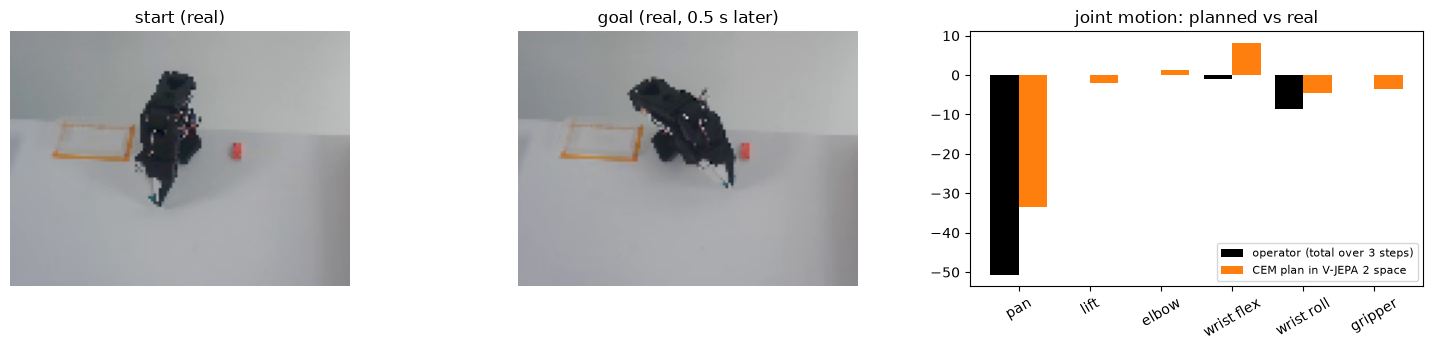

In [10]:
w = sel[0]
z, _, _ = batch(w[None])
plan, _ = cem_plan(z[:, 0], S[w[0]][None].to(device), z[:, -1])
true = A_all[w[:-1]]
JOINTS = ["pan", "lift", "elbow", "wrist flex", "wrist roll", "gripper"]
fig = plt.figure(figsize=(15, 3.6))
ax = fig.add_subplot(1, 3, 1); ax.imshow(thumbs[w[0]].permute(1, 2, 0)); ax.set_title("start (real)"); ax.axis("off")
ax = fig.add_subplot(1, 3, 2); ax.imshow(thumbs[w[-1]].permute(1, 2, 0)); ax.set_title("goal (real, 0.5 s later)"); ax.axis("off")
ax = fig.add_subplot(1, 3, 3)
x = np.arange(6)
ax.bar(x - 0.2, true.sum(0).numpy(), 0.4, label="operator (total over 3 steps)", color="black")
ax.bar(x + 0.2, plan.sum(0).cpu().numpy(), 0.4, label="CEM plan in V-JEPA 2 space", color="tab:orange")
ax.set_xticks(x, JOINTS, rotation=30); ax.set_title("joint motion: planned vs real"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## What you just built

- The encoder never saw this robot and was never trained here — every bit of robot-specific learning lives in a
  ~3M-parameter predictor trained in minutes. That is V-JEPA 2-AC's recipe: **understanding from internet video,
  acting from a little robot data**.
- The planner is LeCun's cognitive architecture in miniature: **perception** = frozen V-JEPA 2, **world model** =
  the action-conditioned predictor, **cost** = distance to the goal's representation, **actor** = CEM.
- With 7 minutes of robot data the planner recovers the direction of the operator's motion for most joints that
  moved, and its imagined trajectories land closer to the goal than doing nothing or acting randomly. Meta's
  version gets from there to zero-shot pick-and-place with a 1B-parameter encoder, 62 hours of data and a real
  robot in the loop.

**Try next:** plan longer horizons (H = 6), use both cameras, keep the full 16×16 token grid, or swap the encoder
for DINOv2 and compare — that's DINO-WM (Lecture 10) vs V-JEPA 2-AC on the same data.